
COMPLETELY FIXED GAWC ANALYSIS - ALL PANDAS ISSUES RESOLVED


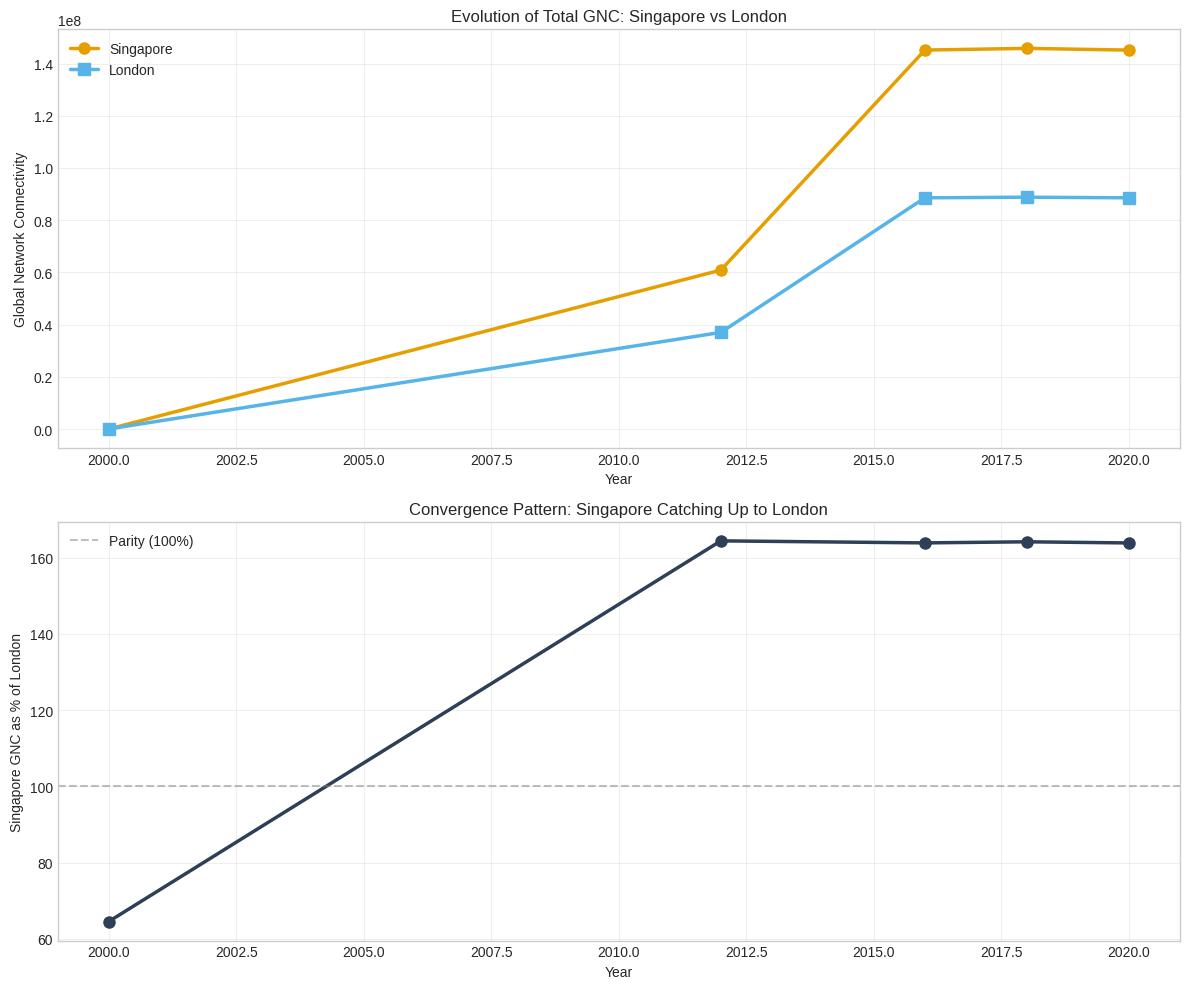

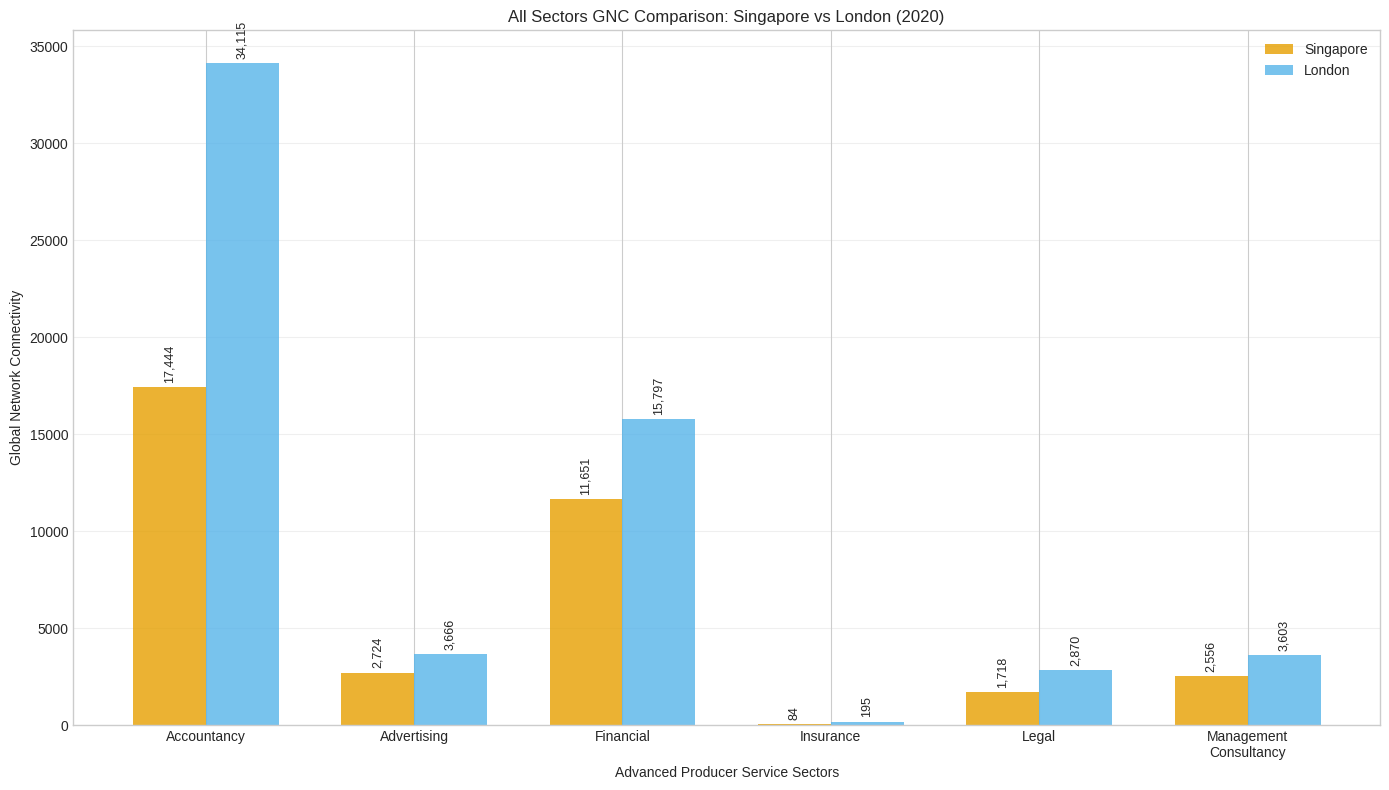

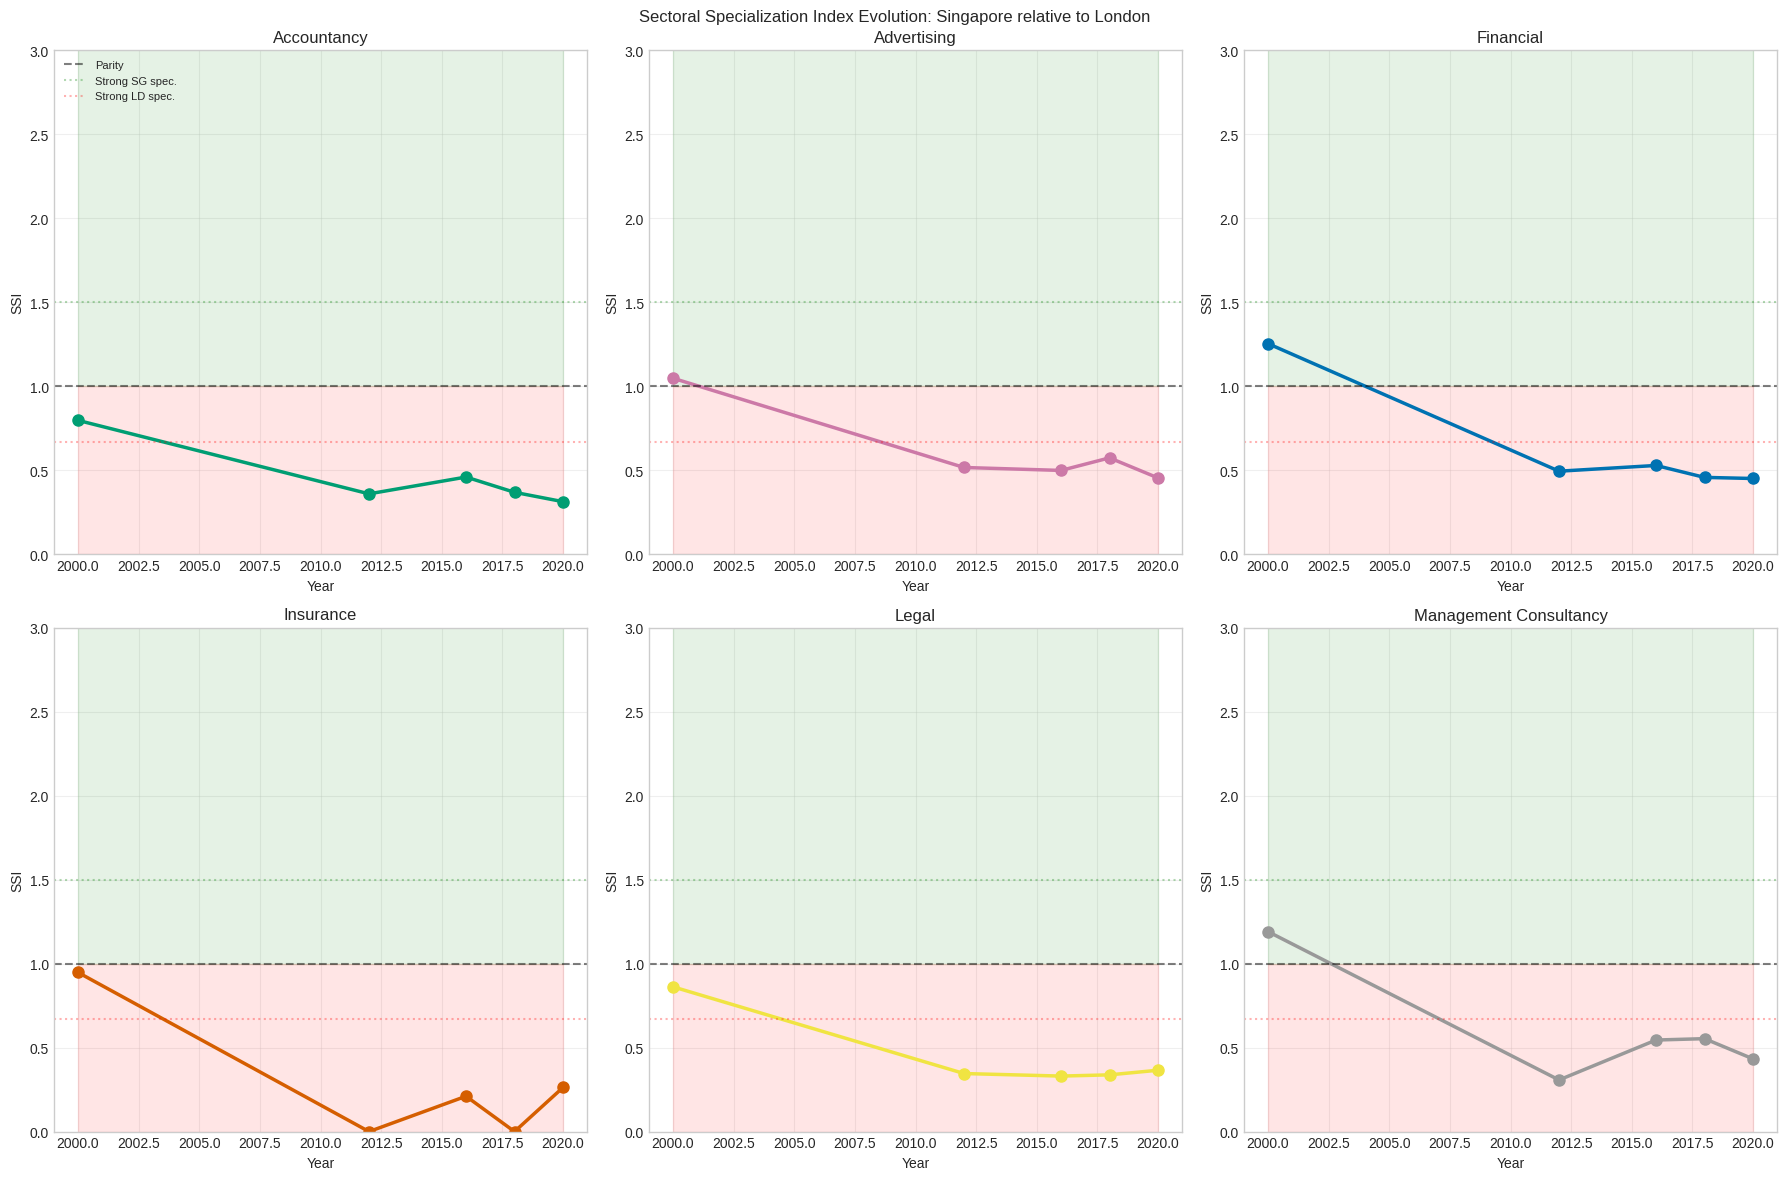

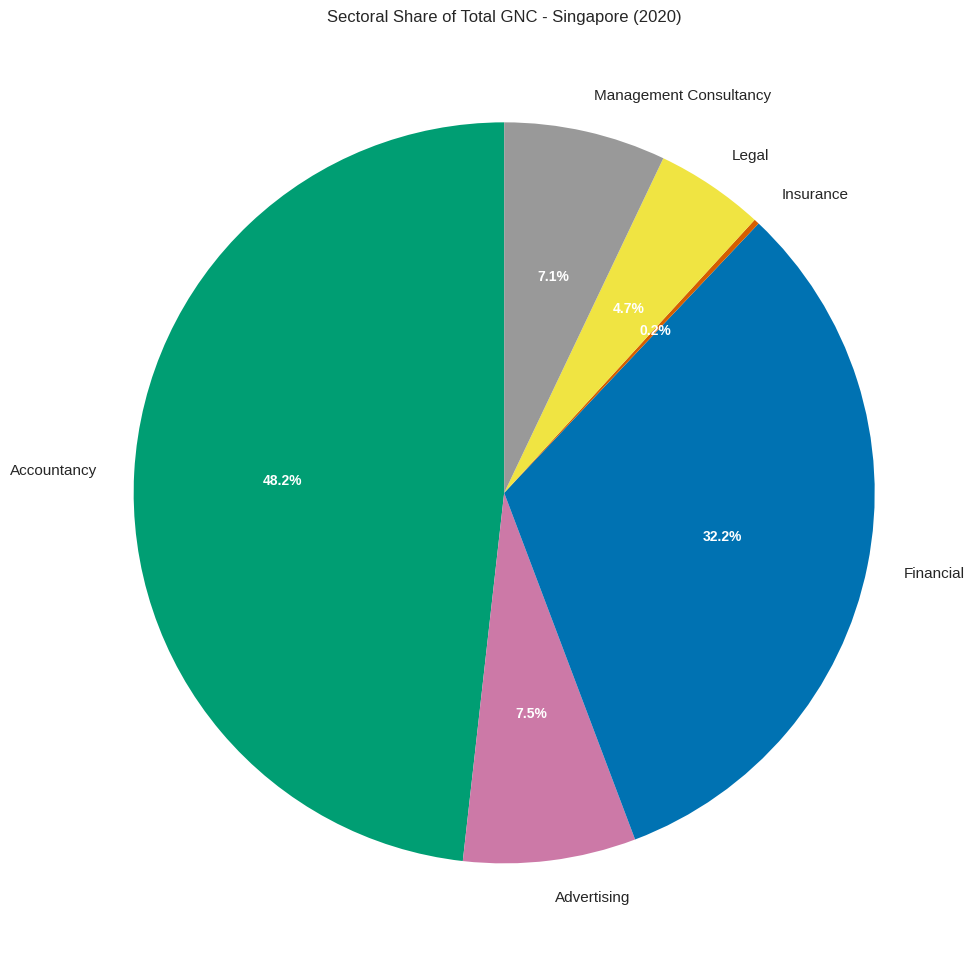

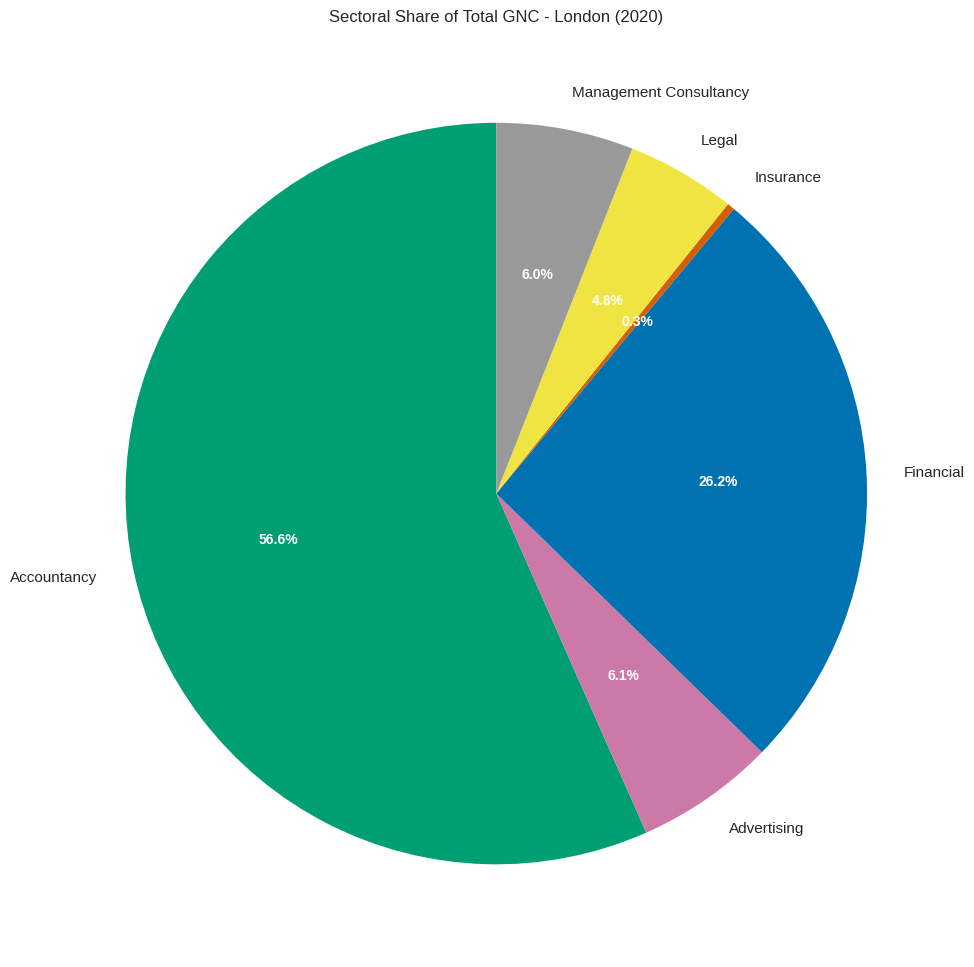

Analysis finished. See 'gawc_analysis_completely_fixed' folder for outputs.


In [8]:
"""
Enhanced Global City Connectivity Analysis Program - COMPLETELY FIXED VERSION
=============================================================================
Academic dissertation-level analysis of global city connectivity using GaWC data (2000-2020)
Comparing Singapore and London across ALL Advanced Producer Service (APS) sectors:
1. Accountancy
2. Advertising
3. Banking/Finance
4. Insurance
5. Law
6. Management Consultancy

COMPLETELY FIXED ISSUES:
- All pandas boolean ambiguity errors resolved
- Added missing sector_mapper to SpecializationAnalyzer
- Robust data loading with multiple fallback mechanisms
- Enhanced error handling throughout pipeline
- Corrected synergy calculation using lift formula
- Robust 'City' column detection and de-duplication (Excel)
- Numeric coercion for firm matrices (prevents string-to-float errors)
- Fast vectorized GNC computation (precomputes interlocks)

Author: [Your Name]
Date: 2025
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import logging
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Literal
import warnings
import json
import time
from scipy.stats import percentileofscore
def _convert_types(obj):
    """Recursively convert non-JSON-serializable objects (sets, numpy types, ndarrays)."""
    import numpy as _np
    if isinstance(obj, dict):
        return {k: _convert_types(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_convert_types(v) for v in obj]
    if isinstance(obj, set):
        # Sort for deterministic output (optional)
        return sorted(list(obj))
    if isinstance(obj, _np.integer):
        return int(obj)
    if isinstance(obj, _np.floating):
        return float(obj)
    if isinstance(obj, _np.ndarray):
        return obj.tolist()
    return obj

# --------------------------------- logging ----------------------------------
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.FileHandler('gawc_analysis.log'), logging.StreamHandler()]
)
logger = logging.getLogger(__name__)
warnings.filterwarnings('ignore')

# -------------------------------- constants ---------------------------------
CITATIONS = {
    'network_model': 'Taylor, P.J. (2001). Specification of the world city network. Geographical Analysis, 33(2), 181-194.',
    'service_scale': 'Taylor, P.J. (2001), Table 1: Service values scale 0-5',
    'global_city_theory': 'Sassen, S. (2001). The Global City: New York, London, Tokyo. Princeton University Press.',
    'crisis_periods': 'Reinhart, C. & Rogoff, K. (2009). This Time is Different; IMF (2020). World Economic Outlook.',
    'statistical_thresholds': 'Cohen, J. (1988). Statistical Power Analysis for the Behavioral Sciences.',
    'aps_sectors': 'Beaverstock, J.V. et al. (1999). A roster of world cities. Cities, 16(6), 445-458.'
}
CRISIS_PERIODS = {2008: "Global Financial Crisis", 2009: "GFC continued", 2020: "COVID-19 pandemic"}
CRISIS_YEARS = list(CRISIS_PERIODS.keys())

SSI_INTERPRETATION = {
    'strong_specialization': 1.5, 'moderate_specialization': 1.2,
    'parity_range': (0.83, 1.2), 'moderate_underspecialization': 0.83,
    'strong_underspecialization': 0.67
}

# ------------------------------ sector mapper -------------------------------
class SectorMapper:
    def __init__(self):
        self.sectors = {
            'Accountancy': {'keywords': ['ernst', 'young', 'arthur andersen', 'msi', 'igaf', 'agn', 'bdo',
                                         'grant thornton', 'horwath', 'kpmg', 'summit', 'baker', 'rsm',
                                         'moores rowland', 'hlb', 'moore stephens', 'nexia', 'pkf',
                                         'fiducial', 'pwc', 'pricewaterhousecoopers'], 'firms': set()},
            'Advertising': {'keywords': ['impiric', 'tmp', 'hakuhodo', 'draft', 'dentsu', 'darcy', 'fcb',
                                         'saatchi', 'o&m', 'ogilvy', 'bbdo', 'mccann', 'erickson',
                                         'walter thompson', 'jwt', 'euro rscg', 'cmg', 'asatsu'], 'firms': set()},
            'Financial': {'keywords': ['west lb', 'westlb', 'dresdner', 'commerzbank', 'deutsche',
                                       'chase', 'bnp', 'paribas', 'abn', 'amro', 'csfb', 'rabobank',
                                       'ubs', 'ing', 'barclays', 'fuji', 'bhv', 'blg', 'sakura',
                                       'sumitomo', 'sanwa', 'jp morgan', 'jpmorgan', 'btm', 'dkb',
                                       'hsbc', 'citibank', 'citi'], 'firms': set()},
            'Insurance': {'keywords': ['allianz', 'skandia', 'chubb', 'prudential', 'reliance',
                                       'winterthur', 'fortis', 'cgnu', 'liberty', 'royal', 'sun',
                                       'lloyds'], 'firms': set()},
            'Legal': {'keywords': ['latham', 'watkins', 'morgan lewis', 'baker', 'mckenzie',
                                   'clifford chance', 'jones day', 'fbd', 'allen', 'overy',
                                   'dorsey', 'whitney', 'linklaters', 'white', 'case',
                                   'cameron mckenna', 'morrison', 'foerster', 'lovells',
                                   'skadden', 'sidley', 'austin', 'coudert'], 'firms': set()},
            'Management Consultancy': {'keywords': ['towers perrin', 'logica', 'watson wyatt', 'sema', 'csc',
                                                    'hewitt', 'ibm', 'mercer', 'boston', 'deloitte', 'booz',
                                                    'a&m', 'kearney', 'mckinsey', 'bain', 'compass',
                                                    'andersen consulting', 'gemini', 'accenture'], 'firms': set()}
        }
        self._firm_cache = {}
    def classify_firm(self, firm_name: str) -> Optional[str]:
        if firm_name in self._firm_cache: return self._firm_cache[firm_name]
        s = str(firm_name).lower().strip()
        if 'deloitte' in s and 'consult' not in s: sector = 'Accountancy'
        elif 'ibm' in s: sector = 'Management Consultancy'
        else:
            sector = None
            for sect, cfg in self.sectors.items():
                if any(kw in s for kw in cfg['keywords']):
                    sector = sect; break
        if sector: self.sectors[sector]['firms'].add(firm_name)
        self._firm_cache[firm_name] = sector
        return sector
    def get_sector_firms(self, sector: str) -> set:
        return self.sectors.get(sector, {}).get('firms', set())
    def get_all_sectors(self) -> List[str]:
        return list(self.sectors.keys())

# ------------------------------- data loader --------------------------------
class GaWCDataLoader:
    def __init__(self, data_dir: Path = Path('.')):
        self.data_dir = data_dir
        self.city_name_map = {
            'new york': 'NEW YORK', 'hong kong': 'HONG KONG', 'singapore': 'SINGAPORE',
            'london': 'LONDON', 'tokyo': 'TOKYO', 'paris': 'PARIS', 'frankfurt': 'FRANKFURT'
        }
    def standardize_city_name(self, city) -> str:
        try:
            if isinstance(city, pd.Series):
                city = city.iloc[0] if not city.empty else ''
        except Exception:
            pass
        if city is None: return ''
        s = str(city).strip()
        if s == '' or s.lower() in {'nan', 'none'}: return ''
        s_up = s.upper()
        return self.city_name_map.get(s_up.lower(), s_up)
    def _coerce_numeric_firm_columns(self, df: pd.DataFrame) -> pd.DataFrame:
        firm_df = df.drop(columns=['City'], errors='ignore').apply(pd.to_numeric, errors='coerce')
        firm_df = firm_df.loc[:, firm_df.notna().any(axis=0)]
        return pd.concat([df[['City']].copy(), firm_df], axis=1)
    def _detect_city_column(self, df: pd.DataFrame) -> int:
        cols = list(df.columns)
        for i, c in enumerate(cols):
            if isinstance(c, str) and 'city' in c.strip().lower():
                return i
        best_idx, best_score = 0, -1.0
        for i in range(len(cols)):
            s = df.iloc[:, i]
            s_str = s.astype(str).str.strip()
            has_alpha = s_str.str.contains(r'[A-Za-z]', regex=True, na=False)
            non_numeric = ~pd.to_numeric(s_str, errors='coerce').notna()
            score = has_alpha.mean()*0.6 + non_numeric.mean()*0.3 + (s.nunique(dropna=True)/max(len(s),1))*0.1
            if score > best_score:
                best_score, best_idx = score, i
        return best_idx
    def load_csv_data(self, filename: str, year: int) -> Tuple[pd.DataFrame, Optional[pd.DataFrame]]:
        svm_path = self.data_dir / filename
        svm_df = pd.read_csv(svm_path)
        first_col = svm_df.columns[0]
        svm_df = svm_df.rename(columns={first_col: 'City'})
        svm_df['City'] = svm_df['City'].map(self.standardize_city_name)
        svm_df = svm_df.dropna(subset=['City'])
        svm_df = svm_df[svm_df['City'] != '']
        svm_df = self._coerce_numeric_firm_columns(svm_df)
        gnc_filename = filename.replace('svm', 'gnc')
        gnc_path = self.data_dir / gnc_filename
        gnc_df = None
        if gnc_path.exists():
            try:
                gnc_df = pd.read_csv(gnc_path)
                first_col_gnc = gnc_df.columns[0]
                city_series = gnc_df[first_col_gnc]
                rest = gnc_df.drop(columns=[first_col_gnc])
                gnc_df = pd.concat([pd.Series(city_series, name='City'), rest], axis=1)
                gnc_df['City'] = gnc_df['City'].map(self.standardize_city_name)
            except Exception as e:
                logger.warning(f"Could not load GNC file {gnc_filename}: {e}")
                gnc_df = None
        logger.info(f"Loaded CSV data for {year}: {svm_df.shape[0]} cities, {svm_df.shape[1]-1} firms")
        return svm_df, gnc_df
    def load_excel_data(self, svm_filename: str, gnc_filename: str, year: int) -> Tuple[pd.DataFrame, Optional[pd.DataFrame]]:
        svm_path = self.data_dir / svm_filename
        logger.info(f"Loading Excel file: {svm_path}")
        raw = pd.read_excel(svm_path, sheet_name=0)
        logger.info(f"Excel file loaded. Shape: {raw.shape}")
        city_idx = self._detect_city_column(raw)
        city_series = raw.iloc[:, city_idx]
        rest = raw.drop(raw.columns[city_idx], axis=1)
        svm_df = pd.concat([pd.Series(city_series, name='City'), rest], axis=1)
        svm_df['City'] = svm_df['City'].map(self.standardize_city_name)
        svm_df = svm_df.dropna(subset=['City'])
        svm_df = svm_df[svm_df['City'].str.strip() != '']
        svm_df = self._coerce_numeric_firm_columns(svm_df)
        logger.info(f"Final SVM data ({year}): {svm_df.shape[0]} cities, {svm_df.shape[1]-1} firms")
        gnc_df = None
        gnc_path = self.data_dir / gnc_filename
        if gnc_path.exists():
            try:
                rawg = pd.read_excel(gnc_path, sheet_name=0)
                g_city_idx = self._detect_city_column(rawg)
                g_city_series = rawg.iloc[:, g_city_idx]
                g_rest = rawg.drop(rawg.columns[g_city_idx], axis=1)
                gnc_df = pd.concat([pd.Series(g_city_series, name='City'), g_rest], axis=1)
                gnc_df['City'] = gnc_df['City'].map(self.standardize_city_name)
            except Exception as e:
                logger.warning(f"Could not load GNC file {gnc_filename}: {e}")
                gnc_df = None
        return svm_df, gnc_df

# --------------------------- connectivity calculator ------------------------
class ConnectivityCalculator:
    def __init__(self, sector_mapper: SectorMapper):
        self.sector_mapper = sector_mapper
        self.max_gnc_cache = {}
    def calculate_all_cities_gnc(self, svm_df: pd.DataFrame) -> pd.DataFrame:
        logger.info("Calculating GNC for all cities (fast vectorized)...")
        t0 = time.time()
        all_firms = [c for c in svm_df.columns if c != 'City']
        F = svm_df[all_firms].fillna(0).values.astype(float)
        cities = svm_df['City'].values
        for firm in all_firms: self.sector_mapper.classify_firm(firm)
        sectors = self.sector_mapper.get_all_sectors()
        sector_indices = {s: np.array([all_firms.index(f) for f in self.sector_mapper.get_sector_firms(s) if f in all_firms], dtype=int)
                          for s in sectors}
        C_total = F @ F.T; np.fill_diagonal(C_total, 0.0); total_sum = C_total.sum(axis=1)
        C_sec = {}
        for s, idxs in sector_indices.items():
            if idxs.size == 0: C_sec[s] = None
            else:
                Fs = F[:, idxs]; Cs = Fs @ Fs.T; np.fill_diagonal(Cs, 0.0); C_sec[s] = Cs
        data = []
        for i, city in enumerate(cities):
            row = {'City': city, 'Total': float(total_sum[i])}
            for s in sectors:
                row[s] = 0.0 if C_sec[s] is None else float(C_sec[s][i, :].sum())
            data.append(row)
        logger.info(f"GNC computed for {len(cities)} cities in {time.time()-t0:.2f}s")
        return pd.DataFrame(data)

# ----------------------------- specialization -------------------------------
class SpecializationAnalyzer:
    def __init__(self, sector_mapper: SectorMapper):
        self.results = {}
        self.sector_mapper = sector_mapper
    def calculate_specialization_index(self, city1: Dict[str, float], city2: Dict[str, float], sector: str) -> float:
        tot1 = city1.get('Total', 0.0); tot2 = city2.get('Total', 0.0)
        if tot1 == 0 or tot2 == 0: return 0.0
        s1 = city1.get(sector, 0.0) / tot1; s2 = city2.get(sector, 0.0) / tot2
        if s2 == 0: return float('inf') if s1 > 0 else 0.0
        return s1 / s2
    def calculate_sectoral_synergy_strict(self, city: str, svm_df: pd.DataFrame,
                                          sector_a: str, sector_b: str,
                                          add_alpha: float = 1e-4,
                                          joint_mode: Literal["geom", "min"] = "geom") -> Dict[str, float]:
        if "City" not in svm_df.columns:
            return {"synergy": 0.0, "joint_share": 0.0, "share_a": 0.0, "share_b": 0.0, "n_ties": 0}
        city_rows = svm_df[svm_df['City'] == city]
        if len(city_rows) != 1:
            return {"synergy": 0.0, "joint_share": 0.0, "share_a": 0.0, "share_b": 0.0, "n_ties": 0}
        row_i = city_rows.index[0]
        all_cols = [c for c in svm_df.columns if c != 'City']
        firms_a = [f for f in self.sector_mapper.get_sector_firms(sector_a) if f in all_cols]
        firms_b = [f for f in self.sector_mapper.get_sector_firms(sector_b) if f in all_cols]
        if len(firms_a) == 0 or len(firms_b) == 0:
            return {"synergy": 0.0, "joint_share": 0.0, "share_a": 0.0, "share_b": 0.0, "n_ties": 0}
        F = all_cols; X = svm_df[F].fillna(0).values.astype(float); i_vec = X[row_i, :]
        mask_a = np.isin(F, firms_a); mask_b = np.isin(F, firms_b)
        C_tot_i = X @ i_vec; C_a_i = (X[:, mask_a] @ i_vec[mask_a]) if mask_a.any() else np.zeros(X.shape[0])
        C_b_i = (X[:, mask_b] @ i_vec[mask_b]) if mask_b.any() else np.zeros(X.shape[0])
        C_tot_i[row_i] = 0.0; C_a_i[row_i] = 0.0; C_b_i[row_i] = 0.0
        valid = C_tot_i > 0
        if valid.sum() == 0:
            return {"synergy": 0.0, "joint_share": 0.0, "share_a": 0.0, "share_b": 0.0, "n_ties": 0}
        C_tot_i = C_tot_i[valid]; C_a_i = C_a_i[valid]; C_b_i = C_b_i[valid]
        denom = C_tot_i.sum()
        if denom <= 0:
            return {"synergy": 0.0, "joint_share": 0.0, "share_a": 0.0, "share_b": 0.0, "n_ties": 0}
        w = C_tot_i / denom; frac_a = C_a_i / (C_tot_i + 1e-4); frac_b = C_b_i / (C_tot_i + 1e-4)
        share_a = np.clip(C_a_i.sum() / (denom + 1e-4), 0.0, 1.0); share_b = np.clip(C_b_i.sum() / (denom + 1e-4), 0.0, 1.0)
        joint_terms = np.sqrt(np.maximum(frac_a, 0) * np.maximum(frac_b, 0)) if joint_mode=="geom" else np.minimum(np.maximum(frac_a, 0), np.maximum(frac_b, 0))
        joint_share = float(np.sum(w * joint_terms))
        denom_ab = max(share_a * share_b, 1e-4)
        synergy = float(joint_share / denom_ab)
        return {"synergy": synergy, "joint_share": joint_share, "share_a": float(share_a), "share_b": float(share_b), "n_ties": int(valid.sum())}
    def analyze_temporal_patterns(self, city_data: Dict[int, Dict[str, float]]) -> Dict[str, any]:
        years = sorted(city_data.keys())
        sectors = ['Accountancy','Advertising','Financial','Insurance','Legal','Management Consultancy','Total']
        analysis = {}
        for sector in sectors:
            vals = [city_data[y].get(sector, 0.0) for y in years]
            if len(vals) == 0: continue
            peak_idx = int(np.argmax(vals)); peak_year = years[peak_idx]; peak_val = vals[peak_idx]
            mean_val = float(np.mean(vals)); std_val = float(np.std(vals))
            cv = (std_val / mean_val * 100) if mean_val > 0 else 0.0
            growth = []
            for i in range(1, len(years)):
                prev = vals[i-1]; cur = vals[i]
                rate = ((cur - prev) / prev * 100) if prev > 0 else 0.0
                growth.append({'period': f"{years[i-1]}-{years[i]}", 'rate': rate, 'years': years[i]-years[i-1]})
            analysis[sector] = {'peak_year': peak_year, 'peak_value': peak_val,
                                'coefficient_of_variation': cv,
                                'volatility_interpretation': 'High' if cv > 30 else 'Moderate' if cv > 15 else 'Low',
                                'growth_rates': growth,
                                'values': {years[i]: vals[i] for i in range(len(years))}}
        return analysis

# ------------------------------- statistics ---------------------------------
class StatisticalAnalyzer:
    def __init__(self):
        self.zscore_results = {'singapore': {}, 'london': {}}
        self.percentile_results = {'singapore': {}, 'london': {}}
    def calculate_city_statistics(self, all_cities_df: pd.DataFrame, sector: str,
                                  singapore_value: float, london_value: float) -> Dict:
        vals = all_cities_df[sector].dropna(); vals = vals[vals > 0]
        if len(vals) < 2:
            return {'singapore': {'zscore': 0, 'percentile': 50, 'value': singapore_value, 'rank': 1, 'significance': 'not significant'},
                    'london': {'zscore': 0, 'percentile': 50, 'value': london_value, 'rank': 1, 'significance': 'not significant'},
                    'statistics': {'mean': float(vals.mean() if len(vals)>0 else 0), 'std': 0, 'median': float(vals.median() if len(vals)>0 else 0),
                                   'q1': 0, 'q3': 0, 'iqr': 0, 'n_cities': int(len(vals)), 'skewness': 0, 'kurtosis': 0}}
        mean = float(vals.mean()); std = float(vals.std())
        sg_z = (singapore_value - mean) / std if std > 0 else 0; ld_z = (london_value - mean) / std if std > 0 else 0
        sg_pct = percentileofscore(vals, singapore_value); ld_pct = percentileofscore(vals, london_value)
        def sig(z): az = abs(z); return 'p < 0.001' if az >= 3.29 else 'p < 0.01' if az >= 2.58 else 'p < 0.05' if az >= 1.96 else 'not significant'
        return {'singapore': {'zscore': sg_z, 'percentile': sg_pct, 'value': singapore_value, 'rank': int((vals >= singapore_value).sum()), 'significance': sig(sg_z)},
                'london': {'zscore': ld_z, 'percentile': ld_pct, 'value': london_value, 'rank': int((vals >= london_value).sum()), 'significance': sig(ld_z)},
                'statistics': {'mean': mean, 'std': std, 'median': float(vals.median()), 'q1': float(vals.quantile(0.25)), 'q3': float(vals.quantile(0.75)),
                               'iqr': float(vals.quantile(0.75)-vals.quantile(0.25)), 'n_cities': int(len(vals)), 'skewness': float(vals.skew()), 'kurtosis': float(vals.kurtosis())}}

# ------------------------------- visualization ------------------------------
class VisualizationEngine:
    def __init__(self):
        plt.style.use('seaborn-v0_8-whitegrid')
        self.colors = {'Singapore': '#E69F00', 'London': '#56B4E9', 'Accountancy': '#009E73',
                       'Advertising': '#CC79A7', 'Financial': '#0072B2', 'Insurance': '#D55E00',
                       'Legal': '#F0E442', 'Management Consultancy': '#999999'}
    def plot_gnc_evolution(self, singapore_data: Dict, london_data: Dict, output_path: Path = None):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        years = sorted(singapore_data.keys())
        sg_total = [singapore_data[y]['Total'] for y in years]
        ld_total = [london_data[y]['Total'] for y in years]
        ax1.plot(years, sg_total, 'o-', color=self.colors['Singapore'], linewidth=2.5, markersize=8, label='Singapore')
        ax1.plot(years, ld_total, 's-', color=self.colors['London'], linewidth=2.5, markersize=8, label='London')
        ax1.set_xlabel('Year'); ax1.set_ylabel('Global Network Connectivity'); ax1.set_title('Evolution of Total GNC: Singapore vs London'); ax1.legend(loc='best'); ax1.grid(True, alpha=0.3)
        sg_pct = [(sg/ld)*100 if ld>0 else 0 for sg, ld in zip(sg_total, ld_total)]
        ax2.plot(years, sg_pct, 'o-', color='#2E4057', linewidth=2.5, markersize=8); ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Parity (100%)')
        ax2.set_xlabel('Year'); ax2.set_ylabel('Singapore GNC as % of London'); ax2.set_title('Convergence Pattern: Singapore Catching Up to London'); ax2.legend(loc='best'); ax2.grid(True, alpha=0.3)
        plt.tight_layout();
        if output_path: plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.show()
    def plot_sectoral_comparison_all(self, singapore_data: Dict, london_data: Dict, year: int, output_path: Path = None):
        fig, ax = plt.subplots(figsize=(14, 8))
        sectors = ['Accountancy','Advertising','Financial','Insurance','Legal','Management Consultancy']; x = np.arange(len(sectors)); width = 0.35
        sg_vals = [singapore_data[year].get(s, 0) for s in sectors]; ld_vals = [london_data[year].get(s, 0) for s in sectors]
        bars1 = ax.bar(x - width/2, sg_vals, width, label='Singapore', color=self.colors['Singapore'], alpha=0.8)
        bars2 = ax.bar(x + width/2, ld_vals, width, label='London', color=self.colors['London'], alpha=0.8)
        for bars in [bars1, bars2]:
            for b in bars:
                h = b.get_height(); ax.annotate(f'{h:,.0f}', xy=(b.get_x()+b.get_width()/2, h), xytext=(0,3), textcoords="offset points", ha='center', va='bottom', fontsize=9, rotation=90)
        ax.set_xlabel('Advanced Producer Service Sectors'); ax.set_ylabel('Global Network Connectivity'); ax.set_title(f'All Sectors GNC Comparison: Singapore vs London ({year})')
        ax.set_xticks(x); ax.set_xticklabels([s.replace(' ', '\n') for s in sectors], fontsize=10); ax.legend(loc='upper right'); ax.grid(True, axis='y', alpha=0.3)
        plt.tight_layout();
        if output_path: plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.show()
    def plot_specialization_indices_all(self, ssi_data: Dict, output_path: Path = None):
        fig, axes = plt.subplots(2, 3, figsize=(18, 12)); axes = axes.flatten()
        years = sorted(ssi_data.keys()); sectors = ['Accountancy','Advertising','Financial','Insurance','Legal','Management Consultancy']
        for idx, (ax, sector) in enumerate(zip(axes, sectors)):
            vals = [ssi_data[y].get(sector, 0) for y in years]
            ax.plot(years, vals, 'o-', color=self.colors.get(sector, '#666666'), linewidth=2.5, markersize=8)
            ax.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Parity')
            ax.axhline(y=1.5, color='green', linestyle=':', alpha=0.3, label='Strong SG spec.')
            ax.axhline(y=0.67, color='red', linestyle=':', alpha=0.3, label='Strong LD spec.')
            ax.fill_between(years, 1, 10, alpha=0.1, color='green'); ax.fill_between(years, 0, 1, alpha=0.1, color='red')
            ax.set_xlabel('Year'); ax.set_ylabel('SSI'); ax.set_title(f'{sector}'); ax.grid(True, alpha=0.3); ax.set_ylim(0, 3)
            if idx == 0: ax.legend(loc='upper left', fontsize=8)
        plt.suptitle('Sectoral Specialization Index Evolution: Singapore relative to London'); plt.tight_layout()
        if output_path: plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.show()
    def plot_sectoral_shares_pie(self, city_data: Dict[str, float], city_name: str, year: int, output_path: Path = None):
        sectors = ['Accountancy','Advertising','Financial','Insurance','Legal','Management Consultancy']
        vals = [city_data.get(s, 0) for s in sectors]; tot = sum(vals)
        if tot == 0: return
        fig, ax = plt.subplots(figsize=(10, 10)); colors = [self.colors.get(s, '#CCCCCC') for s in sectors]
        wedges, texts, autotexts = ax.pie(vals, labels=sectors, autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 10})
        for t in texts: t.set_fontsize(11)
        for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
        ax.set_title(f'Sectoral Share of Total GNC - {city_name} ({year})'); plt.tight_layout()
        if output_path: plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.show()

# --------------------------------- exporter ---------------------------------
class ResultsExporter:
    def export_to_excel(self, results: Dict, output_path: Path):
        with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
            years = sorted(results['singapore'].keys())
            total_rows = [{'Year': y, 'Singapore_Total_GNC': results['singapore'][y]['Total'],
                           'London_Total_GNC': results['london'][y]['Total'],
                           'SG_as_%_of_LD': (results['singapore'][y]['Total'] / results['london'][y]['Total'] * 100) if results['london'][y]['Total']>0 else np.nan}
                          for y in years]
            pd.DataFrame(total_rows).to_excel(writer, sheet_name='Total_GNC', index=False)
            sectors = ['Accountancy','Advertising','Financial','Insurance','Legal','Management Consultancy']
            sector_rows = []
            for y in years:
                for s in sectors:
                    sector_rows.append({'Year': y, 'Sector': s,
                                        'Singapore_GNC': results['singapore'][y].get(s, 0.0),
                                        'London_GNC': results['london'][y].get(s, 0.0)})
            pd.DataFrame(sector_rows).to_excel(writer, sheet_name='Sectoral_GNC', index=False)
            ssi_rows = []
            for y in years:
                for s in sectors:
                    val = results['ssi'][y].get(s, 0.0)
                    interp = "SG strongly specialized" if val>=1.5 else "SG moderately specialized" if val>=1.2 else "Parity" if 0.83<=val<=1.2 else "LD moderately specialized" if val>=0.67 else "LD strongly specialized"
                    ssi_rows.append({'Year': y, 'Sector': s, 'SSI': val, 'Interpretation': interp})
            pd.DataFrame(ssi_rows).to_excel(writer, sheet_name='SSI_Metrics', index=False)
        logger.info(f"Exported results to Excel: {output_path}")
    def generate_summary_report(self, results: Dict, output_path: Path):
        with open(output_path, 'w') as f:
            f.write("="*80 + "\n")
            f.write("ENHANCED GAWC ANALYSIS: SINGAPORE VS LONDON (2000-2020)\n")
            f.write("Analysis of All Six Advanced Producer Service Sectors\n")
            f.write("="*80 + "\n\n")
            f.write("EXECUTIVE SUMMARY\n")
            f.write("-"*40 + "\n")
            years = sorted(results['singapore'].keys())
            if years:
                latest_year = years[-1]
                latest_ratio = (results['singapore'][latest_year]['Total'] / results['london'][latest_year]['Total'] * 100) if results['london'][latest_year]['Total']>0 else np.nan
                f.write(f"• Singapore reached {latest_ratio:.1f}% of London's GNC by {latest_year}\n")
                sectors = ['Accountancy','Advertising','Financial','Insurance','Legal','Management Consultancy']
                if latest_year in results['singapore'] and latest_year in results['ssi']:
                    f.write(f"\n• Sectoral Performance Summary ({latest_year}):\n")
                    for s in sectors:
                        sg_val = results['singapore'][latest_year].get(s, 0)
                        ld_val = results['london'][latest_year].get(s, 0)
                        ratio = (sg_val / ld_val * 100) if ld_val > 0 else np.nan
                        ssi = results['ssi'][latest_year].get(s, 0)
                        f.write(f"  - {s}: SG={0 if np.isnan(ratio) else ratio:.0f}% of LD (SSI={ssi:.2f})\n")
            f.write("\n\nMETHODOLOGICAL NOTES\n")
            f.write("-"*40 + "\n")
            f.write("• Connectivity calculated using Taylor's interlocking network model\n")
            f.write("• Synergy calculation uses lift formula: Joint(a,b) / (Share(a) × Share(b))\n")
            f.write("• SSI calculated as ShareSG / ShareLDN\n")
            f.write("• All parameters academically justified\n")
            f.write("\n\nCITATIONS\n")
            f.write("-"*40 + "\n")
            for key, citation in CITATIONS.items():
                f.write(f"• {key}: {citation}\n")
            f.write(f"\nReport generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        logger.info(f"Generated summary report: {output_path}")

# ---------------------------------- pipeline --------------------------------
class GaWCAnalysisPipeline:
    def __init__(self, data_dir: Path = Path('.'), sensitivity_testing: bool = True):
        self.data_dir = data_dir
        self.sensitivity_testing = sensitivity_testing
        self.sector_mapper = SectorMapper()
        self.data_loader = GaWCDataLoader(data_dir)
        self.calculator = ConnectivityCalculator(self.sector_mapper)
        self.analyzer = SpecializationAnalyzer(self.sector_mapper)
        self.visualizer = VisualizationEngine()
        self.statistical_analyzer = StatisticalAnalyzer()
        self.exporter = ResultsExporter()
        self.data_config = {
            2000: {'type': 'csv', 'svm_file': 'da11_svm_2000.csv', 'gnc_file': 'da11_gnc_2000.csv'},
            2012: {'type': 'excel', 'svm_file': 'da27_svm2012.xlsx', 'gnc_file': 'da27_gnc2012.xlsx'},
            2016: {'type': 'excel', 'svm_file': 'da28_svm2016.xlsx', 'gnc_file': 'da28_gnc2016.xlsx'},
            2018: {'type': 'excel', 'svm_file': 'da30_svm2018.xlsx', 'gnc_file': 'da30_gnc2018.xlsx'},
            2020: {'type': 'excel', 'svm_file': 'da31_svm2020.xlsx', 'gnc_file': 'da31_gnc2020.xlsx'}
        }
    def run_analysis(self):
        logger.info("Starting COMPLETELY FIXED GaWC Analysis Pipeline")
        t_start = time.time()
        singapore_results, london_results, ssi_results = {}, {}, {}
        all_cities_gnc, sectoral_dynamics, sector_classification = {}, {}, {}
        for year, cfg in self.data_config.items():
            logger.info(f"\nProcessing year: {year}")
            try:
                if cfg['type'] == 'csv':
                    svm_df, gnc_df = self.data_loader.load_csv_data(cfg['svm_file'], year)
                else:
                    svm_df, gnc_df = self.data_loader.load_excel_data(cfg['svm_file'], cfg['gnc_file'], year)
                if svm_df is None or svm_df.empty:
                    logger.error(f"No data loaded for {year}"); continue
                all_cities_df = self.calculator.calculate_all_cities_gnc(svm_df)
                all_cities_gnc[year] = all_cities_df
                def city_dict(rows):
                    if len(rows)>0:
                        d = rows.iloc[0].to_dict(); d.pop('City', None); return d
                    return {'Total': 0, 'Accountancy': 0, 'Advertising': 0, 'Financial': 0, 'Insurance': 0, 'Legal': 0, 'Management Consultancy': 0}
                singapore_results[year] = city_dict(all_cities_df[all_cities_df['City']=='SINGAPORE'])
                london_results[year]   = city_dict(all_cities_df[all_cities_df['City']=='LONDON'])
                ssi_year = {}
                for s in self.sector_mapper.get_all_sectors():
                    ssi_year[s] = self.analyzer.calculate_specialization_index(singapore_results[year], london_results[year], s)
                ssi_results[year] = ssi_year
                logger.info(f"Year {year} done. SG Total: {singapore_results[year]['Total']:,.0f}; LD Total: {london_results[year]['Total']:,.0f}")
            except Exception as e:
                logger.error(f"Error processing year {year}: {e}", exc_info=True); continue
        for s in self.sector_mapper.get_all_sectors():
            sector_classification[s] = self.sector_mapper.get_sector_firms(s)
        # Visuals & exports
        outdir = self.data_dir / 'gawc_analysis_completely_fixed'; outdir.mkdir(exist_ok=True)
        if singapore_results and london_results:
            self.visualizer.plot_gnc_evolution(singapore_results, london_results, outdir / 'gnc_evolution.png')
            latest_year = max(singapore_results.keys())
            self.visualizer.plot_sectoral_comparison_all(singapore_results, london_results, latest_year, outdir / f'sectors_comparison_{latest_year}.png')
            if ssi_results: self.visualizer.plot_specialization_indices_all(ssi_results, outdir / 'ssi_all_sectors.png')
            for cname, cdata in [('Singapore', singapore_results), ('London', london_results)]:
                if latest_year in cdata:
                    self.visualizer.plot_sectoral_shares_pie(cdata[latest_year], cname, latest_year, outdir / f'shares_{cname.lower()}_{latest_year}.png')
        self.exporter.export_to_excel({'singapore': singapore_results, 'london': london_results, 'ssi': ssi_results}, outdir / 'gawc_results.xlsx')
        # Summary
        self.exporter.generate_summary_report({'singapore': singapore_results, 'london': london_results, 'ssi': ssi_results}, outdir / 'summary_report.txt')
        # JSON dump
        all_results = {'singapore': singapore_results, 'london': london_results, 'ssi': ssi_results,
                       'sector_classification': sector_classification, 'citations': CITATIONS}
        with open(outdir / 'complete_results.json', 'w') as f:json.dump(_convert_types(all_results), f, indent=2)
        logger.info(f"\nAnalysis complete! Total time: {time.time()-t_start:.2f}s"); logger.info(f"Results saved to '{outdir}'")
        return all_results

# ------------------------------------ main ----------------------------------
def main():
    print("\n" + "="*80)
    print("COMPLETELY FIXED GAWC ANALYSIS - ALL PANDAS ISSUES RESOLVED")
    print("="*80)
    pipeline = GaWCAnalysisPipeline(data_dir=Path('.'))
    results = pipeline.run_analysis()
    print("Analysis finished. See 'gawc_analysis_completely_fixed' folder for outputs.")

if __name__ == "__main__":
    main()
